In [1]:
from pennylane import numpy as np
import pennylane as qml

import pandas as pd
import matplotlib.pyplot as plt

<h1> <center> [Tutorial 3] Variational Quantum Algorithm 활용 연구 소개 1: Variational Quantum Eigensolver </center> <h1>

**The first paper to propose VQA** <br>
A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik, and J. L. O’Brien,<br>
A variational eigenvalue solver on a photonic quantum processor, <Br>
Nature Communications 5, 4213 (2014).

---
## <span style="color:navy"> **1. Problem: Solve Tight-Binding Hamiltonian $\hat{H}_{TB}$** </span>


### <span style="color:gold"> **1-1 Hamiltonian matrix** </span>

$$
\hat{H}_{TB} = \sum_{i',i} |i'\rangle\langle i|
$$

In [2]:
H = np.genfromtxt('data/hamiltonian_matrix.dat')
H

tensor([[-13.01,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.1 ,   0.7 ,   0.  ,   0.  ],
        [  0.  ,  -1.96,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.19,  -3.65,   0.  ,   0.  ],
        [  0.  ,   0.  ,  -1.96,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.55,   0.  ],
        [  0.  ,   0.  ,   0.  ,  -1.96,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.55],
        [  0.  ,   0.  ,   0.  ,   0.  , -13.01,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.1 ,   0.  ,   0.7 ,   0.  ],
        [  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,  -1.96,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.55,   0.  ,   0.  ],
        [  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,  -1.96,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.

In [3]:
n_qubits = np.log2(H.shape[0]).astype(int)
print('# of qubits:', n_qubits)

# of qubits: 4


### <span style="color:gold"> **1-2 Eigenvalues** </span>

In [4]:
H_spectrum = np.linalg.eigvalsh(H)
print("Eigenvalues:", H_spectrum)

Eigenvalues: [-13.83497342 -13.04468236 -13.04468236  -8.93763366  -4.10326094
  -4.10326094  -3.48761854  -1.96        -1.96        -1.96
  -1.96        -1.96        -1.92572286   4.5179433    4.5179433
   4.58594848]


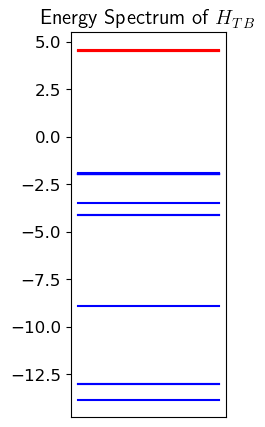

In [5]:
plt.figure(figsize=(2,5))
plt.title("Energy Spectrum of $H_{TB}$", usetex=True, fontsize=15)
plt.xticks(ticks=[])
plt.yticks(fontsize=12)

for y in H_spectrum:
    c = 'blue' if y<0 else 'red'
    plt.plot([0,1], [y]*2, color=c)

---
## <span style="color:navy"> **2. Variational Quantum Eigensolver (VQE)** </span>


<img src="images/vqe_scheme.png" width="70%" height="40%">

### <span style="color:gold"> **2-1 Ansatz: $|\psi(\boldsymbol{\theta})\rangle$** </span>

#### **SU(4)**

In [6]:
def su4(params, wires):
    # Reference 
    # Two-qubit SU(4) gates designed by
    # 1. Farrokh Vatan and Colin Williams, Phys. Rev. A 69, 032315 (2004)
    # 2. V. V. Shende et al., PRA 69 062321 (2004)

    if len(params) != 15:
        print(len(params))
        raise ValueError('len(params) != 15')
    if len(wires) != 2:
        raise ValueError('len(wires) != 2')
    
    qml.Rot(params[0], params[1], params[2], wires=wires[0])
    qml.Rot(params[3], params[4], params[5], wires=wires[1])

    qml.CNOT(wires=[wires[1], wires[0]])

    qml.RZ(params[6], wires=wires[0])
    qml.RY(params[7], wires=wires[1])

    qml.CNOT(wires=[wires[0], wires[1]])

    qml.RY(params[8], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])

    qml.Rot(params[9], params[10], params[11], wires=wires[0])
    qml.Rot(params[12], params[13], params[14], wires=wires[1])

Circuit Diagram

(<Figure size 1000x300 with 1 Axes>, <Axes: >)

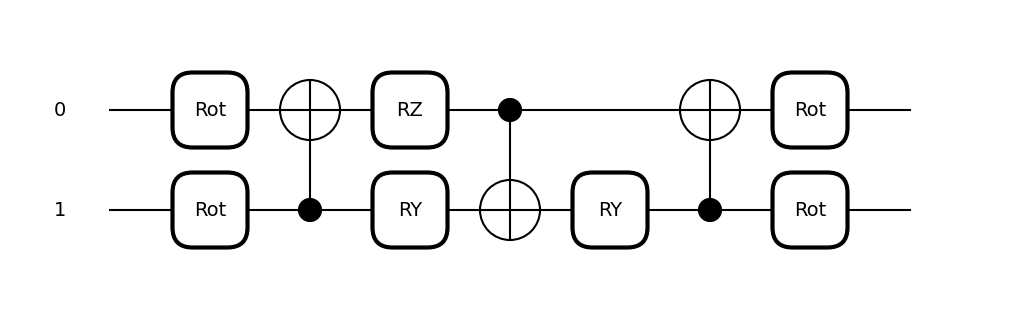

In [7]:
qml.draw_mpl(su4)(np.empty((15)), wires=[0,1])

#### **SU(4)-based Ansatz in Brickwall Pattern**

In [8]:
def su4_brickwall_ansatz(params:np.ndarray, wires:list, n_layers:int, edge_wires="open"):
    n_qubits = len(wires)

    #Sanity Test
    #num_params = '((n_qubits//2) * n_layers, 15)' 
    
    for lth in range(n_layers):
        if n_qubits % 2 == 0:
            for i in range((n_qubits//2) - (lth % 2)):
                su4(params[lth * (n_qubits//2) + i - (lth//2)], wires=[wires[2*i+(lth%2)],wires[2*i+1+(lth%2)]])        
                #print(i)
                #print(lth * (n_qubits//2) + i - lth//2)
            if edge_wires == 'periodic' and lth%2 == 1: 
                su4(params[lth * (n_qubits//2) + i - (lth//2)], wires=[wires[-1], wires[0]])
        else:
            for i in range(n_qubits//2):
                su4(params[lth * (n_qubits//2) + i - (lth//2)], wires=[wires[2*i+(lth%2)],wires[2*i+1+(lth%2)]]) 
                #print(lth * (n_qubits//2) + i)

Circuit Diagram

(<Figure size 3100x500 with 1 Axes>, <Axes: >)

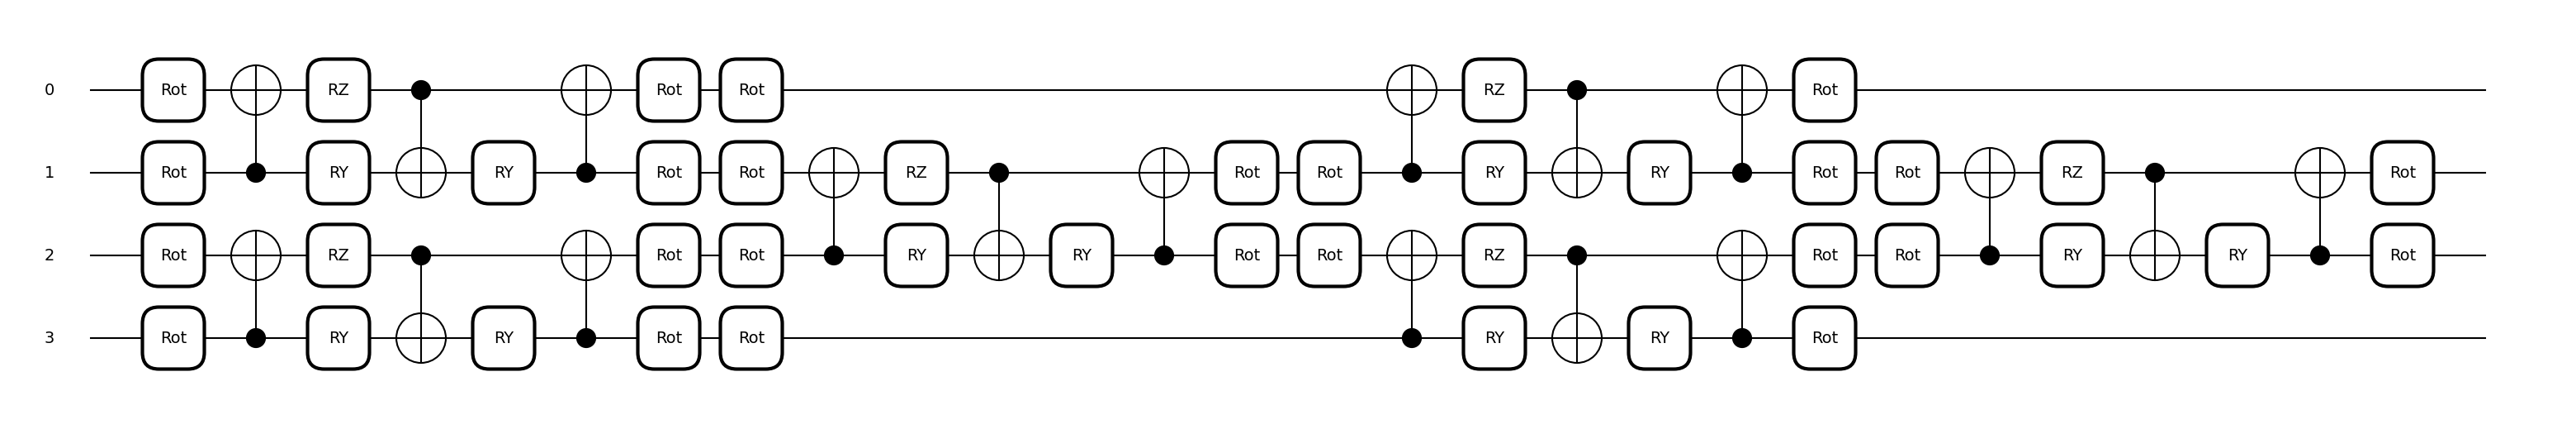

In [9]:
n_qubits, n_layers = 4, 4
num_params = ((n_qubits//2) * n_layers, 15)

qml.draw_mpl(su4_brickwall_ansatz)(np.ones(num_params), range(n_qubits), n_layers)

#### **Hardware Efficient Ansatz**

<img src="images/hea.png" width="45%" height="40%">

In [10]:
def hardware_efficient_ansatz(params, wires, n_layers):
    qml.CZ(wires=[wires[0],wires[1]])

### <span style="color:gold"> **2-2 Cost functions** </span>

#### **$C(\boldsymbol{\theta}) = \langle\psi(\boldsymbol{\theta})|\hat{H}|\psi(\boldsymbol{\theta})\rangle$**

In [32]:
dev = qml.device("default.qubit", wires=4)
H_qml = qml.pauli_decompose(H)

@qml.qnode(dev)
def cost_H(params):
    su4_brickwall_ansatz(params, range(n_qubits), n_layers, "periodic")
    return qml.expval(H_qml)

#### $C(\boldsymbol{\theta}) = \langle\psi(\boldsymbol{\theta})|(\hat{H}-\omega I)^2|\psi(\boldsymbol{\theta})\rangle$

In [12]:
omega = 0
def FS(omega):
    op = np.dot((H - omega*np.eye(2**n_qubits)), (H - omega*np.eye(2**n_qubits)))
    return qml.pauli_decompose(op)
FS_qml = FS(omega)

In [13]:
@qml.qnode(dev)
def cost_FS(params):
    su4_brickwall_ansatz(params, range(n_qubits), n_layers, "periodic")
    return qml.expval(FS_qml)

#### **Evaluating $C(\boldsymbol{\theta})$ from QPUs**

$$
\hat{H} = \sum_{k=0}^{4^N-1} a_k \hat{P}_k \quad\Longrightarrow\quad \langle\hat{H}\rangle = \sum_{k=0}^{4^N-1} a_k \langle\hat{P}_k\rangle, \quad\text{ where }\; a_k = \text{Tr}[\hat{H}\hat{P}_k] / 2^N
$$

In [14]:
pd.DataFrame({
    "Coefficient_1": H_qml.coeffs[:32],
    "Pauli String_1": [str(op) for op in H_qml.ops[:32]],
    "Coefficient_2": H_qml.coeffs[32:64],
    "Pauli String_2": [str(op) for op in H_qml.ops[32:64]],
})

,Coefficient_1,Pauli String_1,Coefficient_2,Pauli String_2
0,-3.66625,I(0) @ I(1) @ I(2) @ I(3),0.06125,X(0) @ Z(1) @ X(2) @ I(3)
1,-2.78125,I(0) @ I(1) @ I(2) @ Z(3),0.06125,X(0) @ Z(1) @ X(2) @ Z(3)
2,-2.78125,I(0) @ I(1) @ Z(2) @ I(3),-0.31875,X(0) @ Z(1) @ Z(2) @ I(3)
3,-2.78125,I(0) @ I(1) @ Z(2) @ Z(3),-0.31875,X(0) @ Z(1) @ Z(2) @ Z(3)
4,-0.45625,I(0) @ X(1) @ I(2) @ I(3),-0.23625,Y(0) @ I(1) @ Y(2) @ I(3)
5,0.31875,I(0) @ X(1) @ I(2) @ Z(3),-0.23625,Y(0) @ I(1) @ Y(2) @ Z(3)
6,-0.06125,I(0) @ X(1) @ X(2) @ X(3),-0.23625,Y(0) @ X(1) @ I(2) @ Y(3)
7,0.06125,I(0) @ X(1) @ Y(2) @ Y(3),-0.23625,Y(0) @ X(1) @ Z(2) @ Y(3)
8,0.31875,I(0) @ X(1) @ Z(2) @ I(3),0.45625,Y(0) @ Y(1) @ I(2) @ I(3)
9,-0.73125,I(0) @ X(1) @ Z(2) @ Z(3),0.06125,Y(0) @ Y(1) @ I(2) @ X(3)


(<Figure size 500x500 with 1 Axes>, <Axes: >)

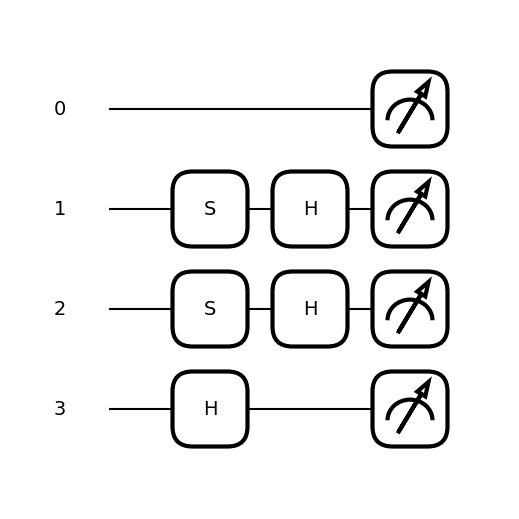

In [15]:
#example: IYYX

def measurement_circuit():
    qml.S(wires=1)
    qml.H(wires=1)
    qml.S(wires=2)
    qml.H(wires=2)
    qml.H(wires=3)
    return qml.counts(wires=range(4))
qml.draw_mpl(measurement_circuit)()

---
## <span style="color:navy"> **3. VQE Simulation** </span>


### <span style="color:gold"> **3-1 Initial Settings** </span>

#### **Parameters for Ansatz**

In [16]:
n_qubits, n_layers = 4, 6
params_size = ((n_qubits//2) * n_layers, 15)

np.random.seed(19) 
params = np.random.uniform(size=params_size) * 2*np.pi

#### **Parameters for Optimization Process**

In [17]:
max_iterations = 1000
step_size = 0.05
conv_tol = 1e-6

### <span style="color:gold"> **3-2 Lowest Eigenvalue** </span> 
$\min_{\boldsymbol{\theta}} \langle\psi(\boldsymbol{\theta})|\hat{H}|\psi(\boldsymbol{\theta})\rangle $

In [18]:
cost_H(params)

tensor(-5.36313445, requires_grad=True)

In [19]:
print(f'\n> Find the lowest eigenpair of <H>')

params_per_step = [params]
cost_per_step = [cost_H(params)]


## Classical Optimizer: Gradient Descent
opt = qml.GradientDescentOptimizer(stepsize=step_size)

for n in range(max_iterations):
    # Optimization
    params, prev_energy = opt.step_and_cost(cost_H, params)
    cost_per_step.append(cost_H(params))
    params_per_step.append(params)

    # Convergence
    #conv = np.abs(cost_per_step[-1] - prev_energy) / np.abs(cost_per_step[-1])
    conv = np.abs(cost_per_step[-1] - prev_energy)

    if n % 50 == 0:
        print(f"  Step = {n},  Cost = {cost_per_step[-1]:.8f}")
        #print("  params:", params_per_step[-1])

    if n == max_iterations-1 or conv <= conv_tol:
        
        print('Total Iterations:', n, end=', ')
        print(f'Cost : {cost_per_step[-1]:.8f}', end=', ')
        print(f'Exact : {H_spectrum[0]:.8f}', end=', ')
        #print(f'Square Root of Cost : {np.sqrt(cost_per_step[-1]):.8f}')
        #self.results['eigen_energies'].append(self.cost_expval_H(params_per_step[-1]))
        #print(f"Eigenenergy : {self.results['eigen_energies'][-1]:.8f}")
        
        break



> Find the lowest eigenpair of <H>
  Step = 0,  Cost = -9.10730380
  Step = 50,  Cost = -11.90681739
  Step = 100,  Cost = -13.37674921
  Step = 150,  Cost = -13.64819879
  Step = 200,  Cost = -13.76771231
  Step = 250,  Cost = -13.71361483
  Step = 300,  Cost = -13.79573148
  Step = 350,  Cost = -13.80262612
  Step = 400,  Cost = -13.81305753
  Step = 450,  Cost = -13.80117484
  Step = 500,  Cost = -13.82483883
  Step = 550,  Cost = -13.83279473
  Step = 600,  Cost = -13.83434588
Total Iterations: 613, Cost : -13.83440688, Exact : -13.83497342, 

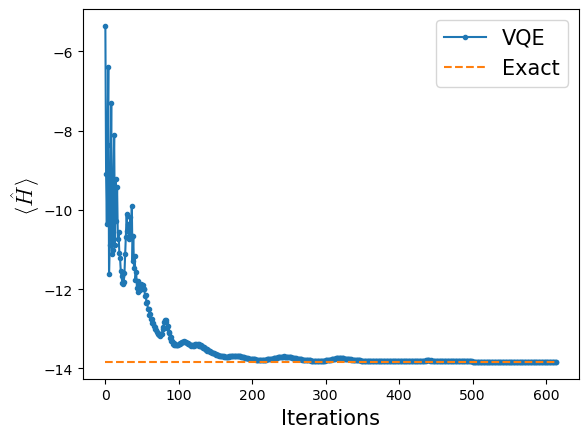

In [20]:
plt.plot(range(len(cost_per_step)), cost_per_step, '.-', label='VQE')
plt.plot(range(len(cost_per_step)), [H_spectrum[0]]*len(cost_per_step), '--', label='Exact')
#plt.title('Tight-Binding Hamiltonian Simulation', fontsize=15)
plt.ylabel(r'$\langle \hat{H} \rangle$', usetex=True, fontsize=17)
plt.xlabel('Iterations', fontsize=15)
plt.legend(fontsize=15)
plt.show()

### <span style="color:gold"> **3-3 Eigenvalue close to $\omega$** </span> 
$\min_{\boldsymbol{\theta}} \langle\psi(\boldsymbol{\theta})|(\hat{H}-\omega I)^2|\psi(\boldsymbol{\theta})\rangle $

In [44]:
n_qubits, n_layers = 4, 8
params_size = ((n_qubits//2) * n_layers, 15)

np.random.seed(19) 
params = np.random.uniform(size=params_size) * 2*np.pi

In [45]:
max_iterations = 1500
step_size = 0.005
conv_tol = 1e-7

In [46]:
params = np.random.uniform(size=params_size) * 2*np.pi
FS_qml = FS(0)

In [47]:
print(f'\n> Find the lowest eigenpair of <H>')

params_per_step = [params]
cost_per_step = [cost_FS(params)]


## Classical Optimizer: Gradient Descent
opt = qml.GradientDescentOptimizer(stepsize=step_size)

for n in range(max_iterations):
    # Optimization
    params, prev_energy = opt.step_and_cost(cost_FS, params)
    cost_per_step.append(cost_FS(params))
    params_per_step.append(params)

    # Convergence
    #conv = np.abs(cost_per_step[-1] - prev_energy) / np.abs(cost_per_step[-1])
    conv = np.abs(cost_per_step[-1] - prev_energy)

    if n % 50 == 0:
        print(f"  Step = {n},  Cost = {cost_per_step[-1]:.8f}")
        #print("  params:", params_per_step[-1])

    if n == max_iterations-1 or conv <= conv_tol:
        
        print('Total Iterations:', n, end=', ')
        print(f'Cost : {cost_per_step[-1]:.8f}', end=', ')
        print(f'<H> : {cost_H(params_per_step[-1]):.8f}', end=', ')
        #print(f'Square Root of Cost : {np.sqrt(cost_per_step[-1]):.8f}')
        #self.results['eigen_energies'].append(self.cost_expval_H(params_per_step[-1]))
        #print(f"Eigenenergy : {self.results['eigen_energies'][-1]:.8f}")
        
        break



> Find the lowest eigenpair of <H>
  Step = 0,  Cost = 49.15828765
  Step = 50,  Cost = 3.83451300
  Step = 100,  Cost = 3.83038840
  Step = 150,  Cost = 3.82837468
  Step = 200,  Cost = 3.82611087
  Step = 250,  Cost = 3.82358024
  Step = 300,  Cost = 3.82079084
  Step = 350,  Cost = 3.81776293
  Step = 400,  Cost = 3.81452848
  Step = 450,  Cost = 3.81112900
  Step = 500,  Cost = 3.80761185
  Step = 550,  Cost = 3.80402577
  Step = 600,  Cost = 3.80041663
  Step = 650,  Cost = 3.79682412
  Step = 700,  Cost = 3.79327995
  Step = 750,  Cost = 3.78980735
  Step = 800,  Cost = 3.78642168
  Step = 850,  Cost = 3.78313163
  Step = 900,  Cost = 3.77994068
  Step = 950,  Cost = 3.77684856
  Step = 1000,  Cost = 3.77385255
  Step = 1050,  Cost = 3.77094857
  Step = 1100,  Cost = 3.76813201
  Step = 1150,  Cost = 3.76539832
  Step = 1200,  Cost = 3.76410092
  Step = 1250,  Cost = 3.77232303
  Step = 1300,  Cost = 3.76087770
  Step = 1350,  Cost = 3.75818588
  Step = 1400,  Cost = 3.75561826


[  3.70840855   3.8416       3.8416       3.8416       3.8416
   3.8416      12.16348309  16.83675036  16.83675036  20.41181171
  20.41181171  21.03092348  79.88129541 170.16373793 170.16373793
 191.40648947]


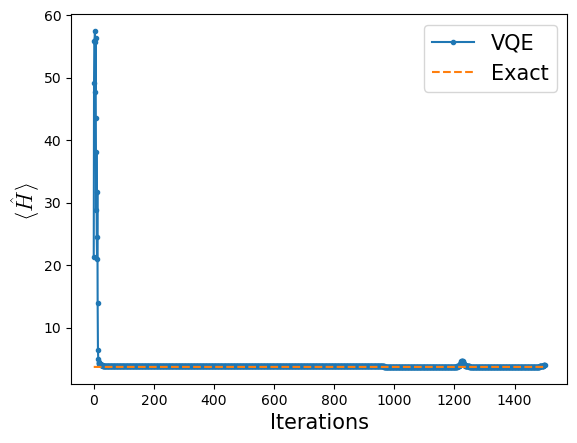

In [48]:
FS_spectrum = np.linalg.eigvalsh(np.dot((H - omega*np.eye(2**n_qubits)), (H - omega*np.eye(2**n_qubits))))
print(FS_spectrum)

plt.plot(range(len(cost_per_step)), cost_per_step, '.-', label='VQE')
plt.plot(range(len(cost_per_step)), [FS_spectrum[0]]*len(cost_per_step), '--', label='Exact')
#plt.title('Tight-Binding Hamiltonian Simulation', fontsize=15)
plt.ylabel(r'$\langle \hat{H} \rangle$', usetex=True, fontsize=17)
plt.xlabel('Iterations', fontsize=15)
plt.legend(fontsize=15)
plt.show()

---
---